# KNN

### 1. Imports

In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from funciones_rafa import *
import joblib

### 2. Carga, division y escalado del Dataset

In [2]:
SPOOF = "..\\..\\Dataset\\Features\\spoof_features.csv"
BONAFIDE = "..\\..\\Dataset\\Features\\bonafide_features.csv"
RANDOM_STATE = 1221182

In [3]:
df = carga_datos(ruta_bon=BONAFIDE, ruta_spo=SPOOF, random_state=RANDOM_STATE)

In [4]:
X = df.drop(columns=['label', 'filename'])
y = df['label']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Entrenamiento y evaluación de modelos

#### 3.1. Baseline

In [9]:
# Entrenamos el modelo con los parámetros por defecto
knn_baseline = KNeighborsClassifier()
knn_baseline.fit(X=X_train_scaled, y=y_train)

KNeighborsClassifier()

In [9]:
# Predicciones
y_pred_base = knn_baseline.predict(X_test_scaled)
y_pred_proba_base = knn_baseline.predict_proba(X_test_scaled)


==================== KNN Baseline ====================

Métricas principales:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC AUC:   1.0000
Matthews Correlation Coefficient: 1.0000

Análisis de errores:
Verdaderos Negativos (Reales bien clasificados): 10
Verdaderos Positivos (IA bien clasificados): 10
Falsos Positivos (Reales clasificados como IA): 0
Falsos Negativos (IA clasificados como Reales): 0
Error tipo I (Falsos Positivos): 0.00%
Error tipo II (Falsos Negativos): 0.00%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Real (1)     1.0000    1.0000    1.0000        10
      IA (0)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


Matriz de Confusión:


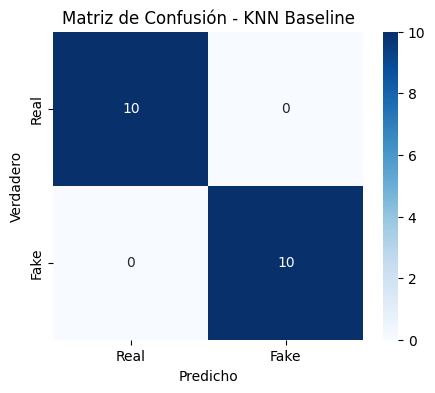

In [10]:
# Evaluación usando tu función de funciones.py
metrics_base = evaluacion_modelo("KNN Baseline", y_test, y_pred_base, y_pred_proba_base)

#### 3.2. Validación cruzada

In [11]:
# Definimos la estrategia de validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [12]:
# Evaluamos con diferentes métricas
cv_scores_accuracy = cross_val_score(knn_baseline, X_train, y_train, cv=skf, scoring='accuracy')
cv_scores_f1 = cross_val_score(knn_baseline, X_train, y_train, cv=skf, scoring='f1')
cv_scores_auc = cross_val_score(knn_baseline, X_train, y_train, cv=skf, scoring='roc_auc')

In [13]:
print("\nResultados Validación Cruzada (5 folds):")
print(f"   • Accuracy: {cv_scores_accuracy.mean():.4f} (+/- {cv_scores_accuracy.std()*2:.4f})")
print(f"   • F1-Score: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std()*2:.4f})")
print(f"   • AUC-ROC:  {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std()*2:.4f})")


Resultados Validación Cruzada (5 folds):
   • Accuracy: 0.8875 (+/- 0.0935)
   • F1-Score: 0.8877 (+/- 0.1012)
   • AUC-ROC:  0.9422 (+/- 0.1076)


#### 3.3. Grid search

In [14]:
# Definimos el espacio de búsqueda
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [15]:
# Ejecutamos el Grid Search con la misma estrategia estratificada
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=skf, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)
print(f"Mejores parámetros: {grid_knn.best_params_}")

Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}



==================== KNN Optimizado (Grid Search) ====================

Métricas principales:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC AUC:   1.0000
Matthews Correlation Coefficient: 1.0000

Análisis de errores:
Verdaderos Negativos (Reales bien clasificados): 10
Verdaderos Positivos (IA bien clasificados): 10
Falsos Positivos (Reales clasificados como IA): 0
Falsos Negativos (IA clasificados como Reales): 0
Error tipo I (Falsos Positivos): 0.00%
Error tipo II (Falsos Negativos): 0.00%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Real (1)     1.0000    1.0000    1.0000        10
      IA (0)     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20


Matriz de Confusión:


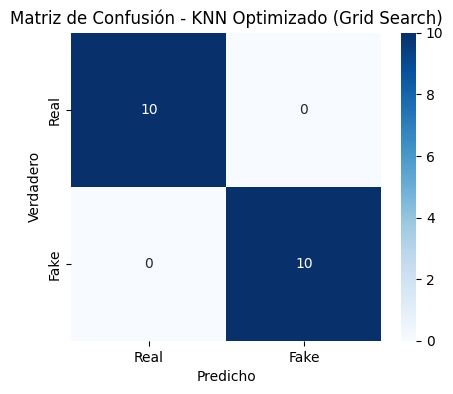

In [16]:
# Evaluamos el mejor modelo encontrado
best_knn = grid_knn.best_estimator_
y_pred_opt = best_knn.predict(X_test_scaled)
y_pred_proba_opt = best_knn.predict_proba(X_test_scaled)

metrics_opt = evaluacion_modelo("KNN Optimizado (Grid Search)", y_test, y_pred_opt, y_pred_proba_opt)

### 4. Guardado del scaler y el mejor modelo

In [ ]:
joblib.dump(best_knn, 'modelo_knn.pkl')
joblib.dump(scaler, 'scaler_knn.pkl')

print("Modelo y escalador guardados correctamente.")

Modelo y escalador guardados correctamente.
